Perform dimensionality reduction + feature importance on obtained features

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [3]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/final_dataset.csv')

# Display the first few rows and column information to understand the data
display(df.head())
print(df.info())

,HARPNUM,time,mean_B,max_B,min_B,std_B,positive_flux,negative_flux,polarity_mixing,polarity_separation,...,aspect_ratio,solidity,circularity,mean_intensity,max_intensity,min_intensity,contrast,entropy,NOAA_AR,flare_class
0,6591,2016-06-01T22:59:46,-10.158483,286.2,-609.9,35.216641,113196.6,666305.7,-553109.1,29.197368,...,2.877777,0.900990,0.622219,0.746111,0.968627,0.505882,0.462745,6.205202,12550.0,NaN
1,6591,2016-06-02T22:59:58,13.880187,476.6,-236.4,43.872722,330400.9,57460.9,272940.0,39.064410,...,2.877777,0.900990,0.622219,0.746111,0.968627,0.505882,0.462745,6.205202,12550.0,NaN
2,6599,2016-06-08T23:00:10,-0.575392,368.3,-271.8,16.109726,120342.5,142087.7,-21745.2,6.729992,...,2.200381,0.686144,0.380092,0.495100,0.925490,0.266667,0.658824,6.732253,12552.0,C
3,6599,2016-06-08T23:00:10,-0.575392,368.3,-271.8,16.109726,120342.5,142087.7,-21745.2,6.729992,...,1.202083,0.850722,0.663025,0.528206,0.850980,0.278431,0.572549,6.634585,12552.0,C
4,6599,2016-06-09T23:00:10,2.283636,594.4,-356.4,22.606733,253592.8,154355.1,99237.7,3.232973,...,2.200381,0.686144,0.380092,0.495100,0.925490,0.266667,0.658824,6.732253,12552.0,C


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HARPNUM              216 non-null    int64  
 1   time                 216 non-null    object 
 2   mean_B               216 non-null    float64
 3   max_B                216 non-null    float64
 4   min_B                216 non-null    float64
 5   std_B                216 non-null    float64
 6   positive_flux        216 non-null    float64
 7   negative_flux        216 non-null    float64
 8   polarity_mixing      216 non-null    float64
 9   polarity_separation  216 non-null    float64
 10  mean_gradient        216 non-null    float64
 11  magnetic_energy      216 non-null    float64
 12  area                 216 non-null    float64
 13  perimeter            216 non-null    float64
 14  aspect_ratio         216 non-null    float64
 15  solidity             216 non-null    flo

# 1) feature correlation

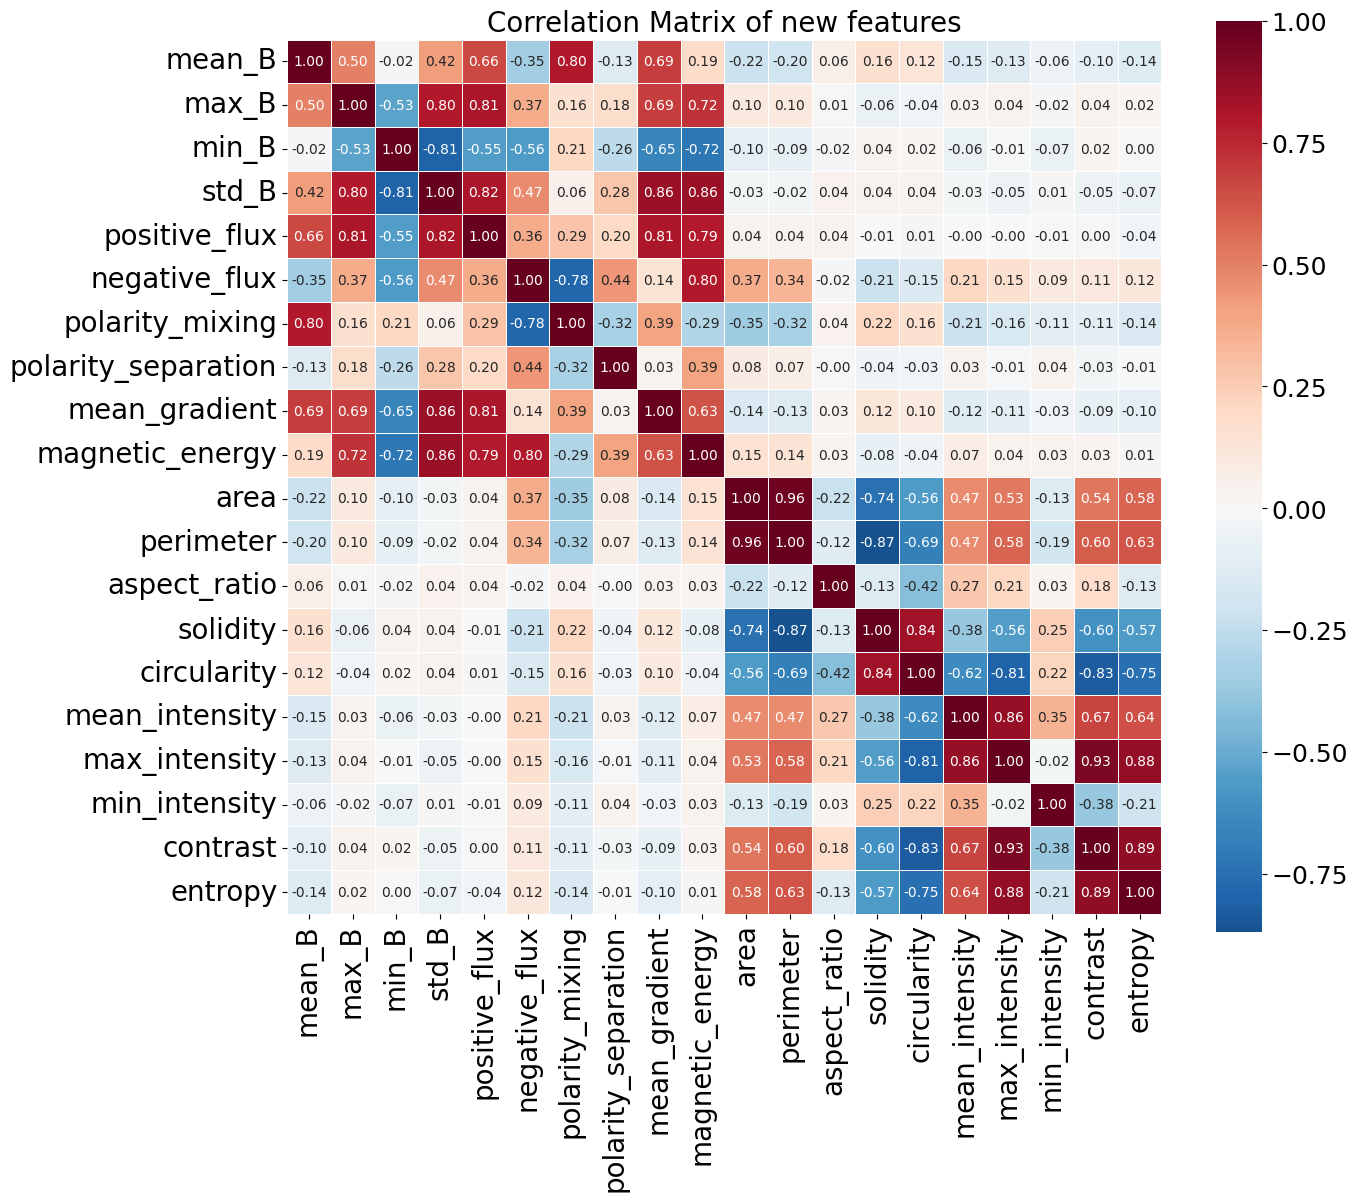

In [4]:
# import parameters
parameters = [
    'mean_B', 'max_B', 'min_B', 'std_B', 'positive_flux', 'negative_flux', 'polarity_mixing',
    'polarity_separation', 'mean_gradient', 'magnetic_energy', 'area', 'perimeter', 'aspect_ratio', 'solidity',
    'circularity', 'mean_intensity', 'max_intensity', 'min_intensity', 'contrast', 'entropy'
]

# Select only relevant columns
df_params = df[parameters]

# Compute correlation matrix
corr = df_params.corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
ax = sns.heatmap(corr,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            square=True)

# For report
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)

plt.title("Correlation Matrix of new features", fontsize=20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

In [5]:
def remove_highly_correlated_features(df, threshold):
    """
    Removes one of a pair of highly correlated features from a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        threshold (float): The correlation threshold (absolute value).

    Returns:
        pd.DataFrame: A new DataFrame with highly correlated features removed.
        list: A list of the columns that were removed.
    """
    corr = df.corr().abs()
    upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Find features with correlation greater than the threshold
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] >= threshold)]

    df_reduced = df.drop(columns=to_drop)
    return df_reduced, to_drop

In [6]:
df_reduced, reduced = remove_highly_correlated_features(df_params[parameters], threshold=0.7)

print(f"Original `df_sharp` shape: {df_reduced.shape}")
print(f"Features removed: {reduced}")
print(f"`df_reduced` shape: {df_reduced.shape}")

Original `df_sharp` shape: (216, 9)
Features removed: ['std_B', 'positive_flux', 'polarity_mixing', 'mean_gradient', 'magnetic_energy', 'perimeter', 'solidity', 'circularity', 'max_intensity', 'contrast', 'entropy']
`df_reduced` shape: (216, 9)


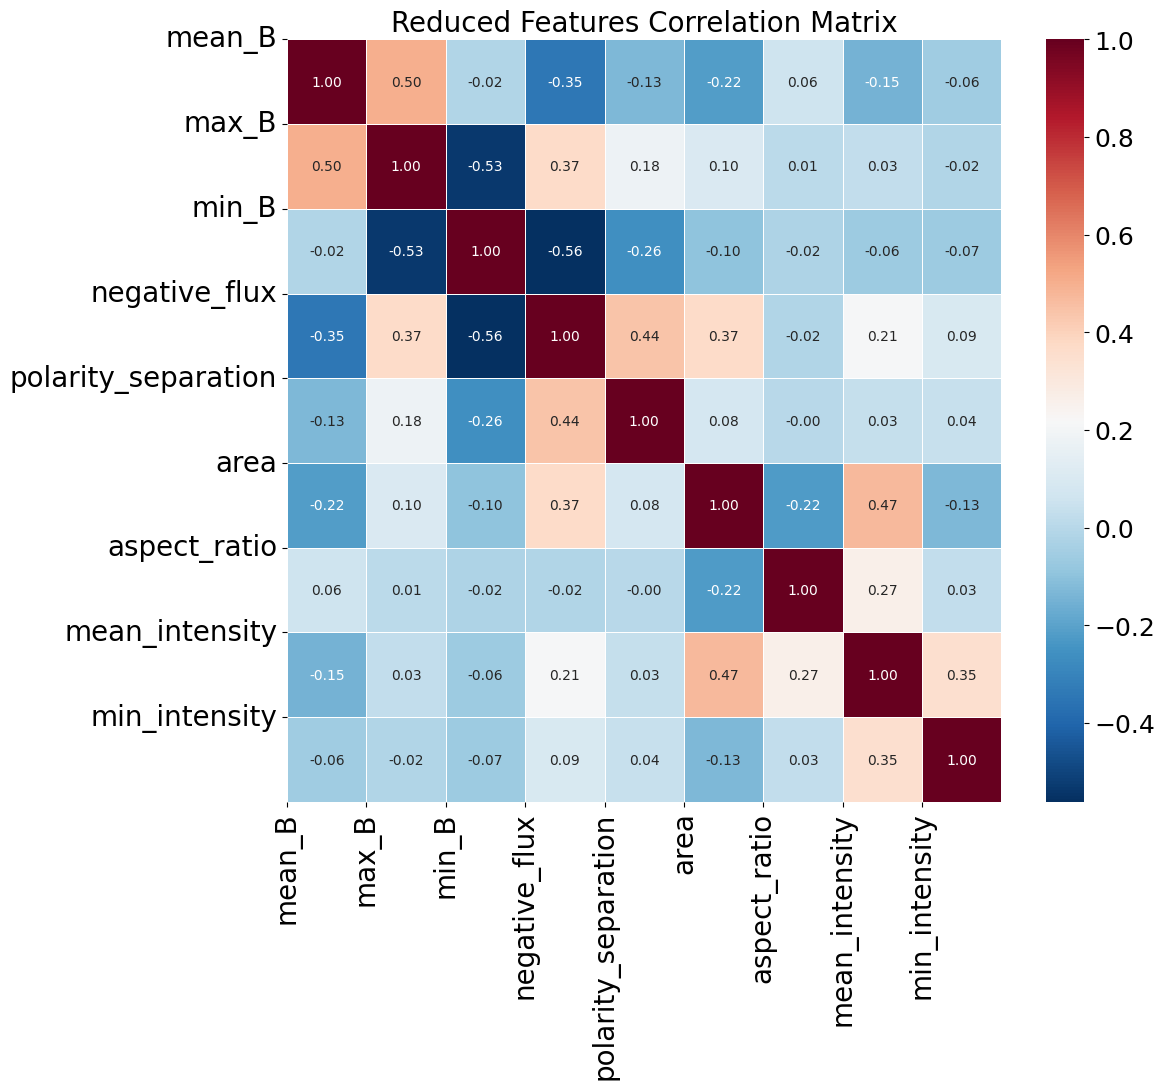

In [7]:
# Compute new correlation matrix
corr_matrix_new = df_reduced.corr()

# Plot the reduced correlation matrix
plt.figure(figsize=(12, 11))
ax = sns.heatmap(corr_matrix_new,
            cmap='RdBu_r',
            annot=True,
            fmt=".2f",
            linewidths=0.5)

# For report
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)

plt.xticks(range(len(corr_matrix_new.columns)),
           corr_matrix_new.columns,
           rotation=90, fontsize=20)

plt.yticks(range(len(corr_matrix_new.columns)),
           corr_matrix_new.columns,
           rotation=0, fontsize=20)

plt.title("Reduced Features Correlation Matrix", fontsize=20)
plt.tight_layout()
plt.savefig('correlation_matrix_07.png')
plt.show()


# Save remaining parameters
params_corr = df_reduced.columns.tolist()

# 2) duplicating flares

In [8]:
# Original flare distribution
print("Unique values:", df['flare_class'].unique())
print("NaN entries (non-flaring):", df['flare_class'].isna().sum())
print("C flares:", (df['flare_class'] == "C").sum())
print("M flares:", (df['flare_class'] == "M").sum())
print("X flares:", (df['flare_class'] == "X").sum())


Unique values: [nan 'C' 'B' 'M']
NaN entries (non-flaring): 35
C flares: 86
M flares: 45
X flares: 0


So apparently our sample has more flaring events than non flaring events. lol

In [9]:
flare_classes = {'C', 'M', 'X'}
df['is_flare'] = df['flare_class'].apply(
    lambda x: 1 if (not pd.isna(x) and x in flare_classes) else 0
)

# Separate classes
df_flares = df[df['is_flare'] == 1]
df_non_flares = df[df['is_flare'] == 0]

n_flares = len(df_flares)
n_non_flares = len(df_non_flares)

print(f"Before balancing — Flaring: {n_flares}, Non-flaring: {n_non_flares}")

# Oversample non-flaring events (minority) to match flaring events (majority)
df_non_flares_upsampled = df_non_flares.sample(n=n_flares, replace=True, random_state=42)

# Combine into balanced dataset
df_balanced = pd.concat([df_flares, df_non_flares_upsampled])

# Shuffle dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Final counts for verification
n_flares_bal = df_balanced['is_flare'].sum()
n_non_flares_bal = len(df_balanced) - n_flares_bal

print(f"After balancing  — Flaring: {n_flares_bal}, Non-flaring: {n_non_flares_bal}")

Before balancing — Flaring: 131, Non-flaring: 85
After balancing  — Flaring: 131, Non-flaring: 131


# 3) Feature importance

Accuracy: 0.981

Classification Report:
              precision    recall  f1-score   support

   Non-flare       1.00      0.96      0.98        27
       Flare       0.96      1.00      0.98        26

    accuracy                           0.98        53
   macro avg       0.98      0.98      0.98        53
weighted avg       0.98      0.98      0.98        53

               feature  importance
8        min_intensity    0.190939
3        negative_flux    0.160163
6         aspect_ratio    0.142097
5                 area    0.141753
1                max_B    0.089909
7       mean_intensity    0.080899
2                min_B    0.074682
0               mean_B    0.070462
4  polarity_separation    0.049096


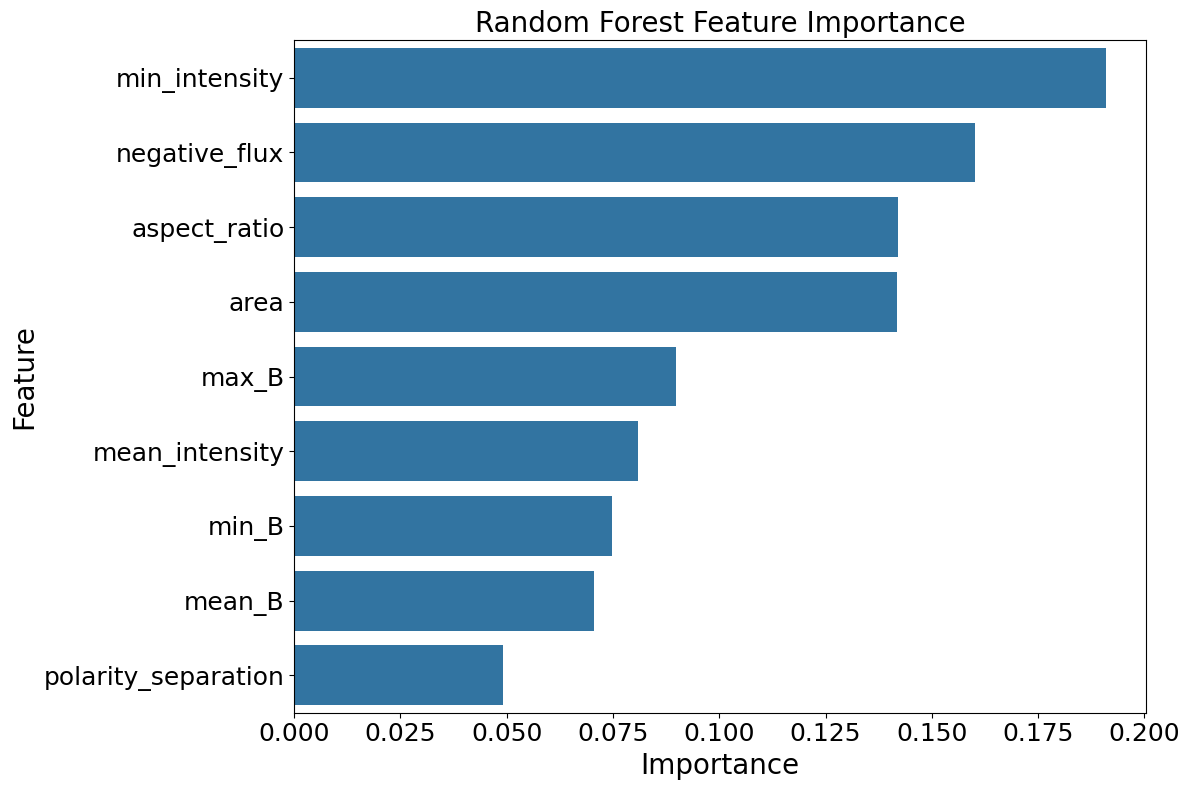

In [18]:
# Features and target
X = df_balanced[params_corr]
y = df_balanced['is_flare']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Evaluate model
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-flare', 'Flare']))

# Feature importance
importances = rf_model.feature_importances_

# Create dataframe for visualization
feat_importance_df = pd.DataFrame({
    'feature': params_corr,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_importance_df)

# Plot feature importance
plt.figure(figsize=(12, 8))
ax= sns.barplot(data=feat_importance_df,
            x='importance',
            y='feature')
ax.tick_params(axis='both', labelsize=18)

plt.title("Random Forest Feature Importance", fontsize=20)
plt.xlabel("Importance", fontsize = 20)
plt.ylabel("Feature", fontsize=20)
plt.tight_layout()
plt.show()

Accuracy: 0.981

Classification Report:
              precision    recall  f1-score   support

   Non-flare       1.00      0.96      0.98        27
       Flare       0.96      1.00      0.98        26

    accuracy                           0.98        53
   macro avg       0.98      0.98      0.98        53
weighted avg       0.98      0.98      0.98        53

TSS: 0.963
               feature  importance
8        min_intensity    0.190939
3        negative_flux    0.160163
6         aspect_ratio    0.142097
5                 area    0.141753
1                max_B    0.089909
7       mean_intensity    0.080899
2                min_B    0.074682
0               mean_B    0.070462
4  polarity_separation    0.049096


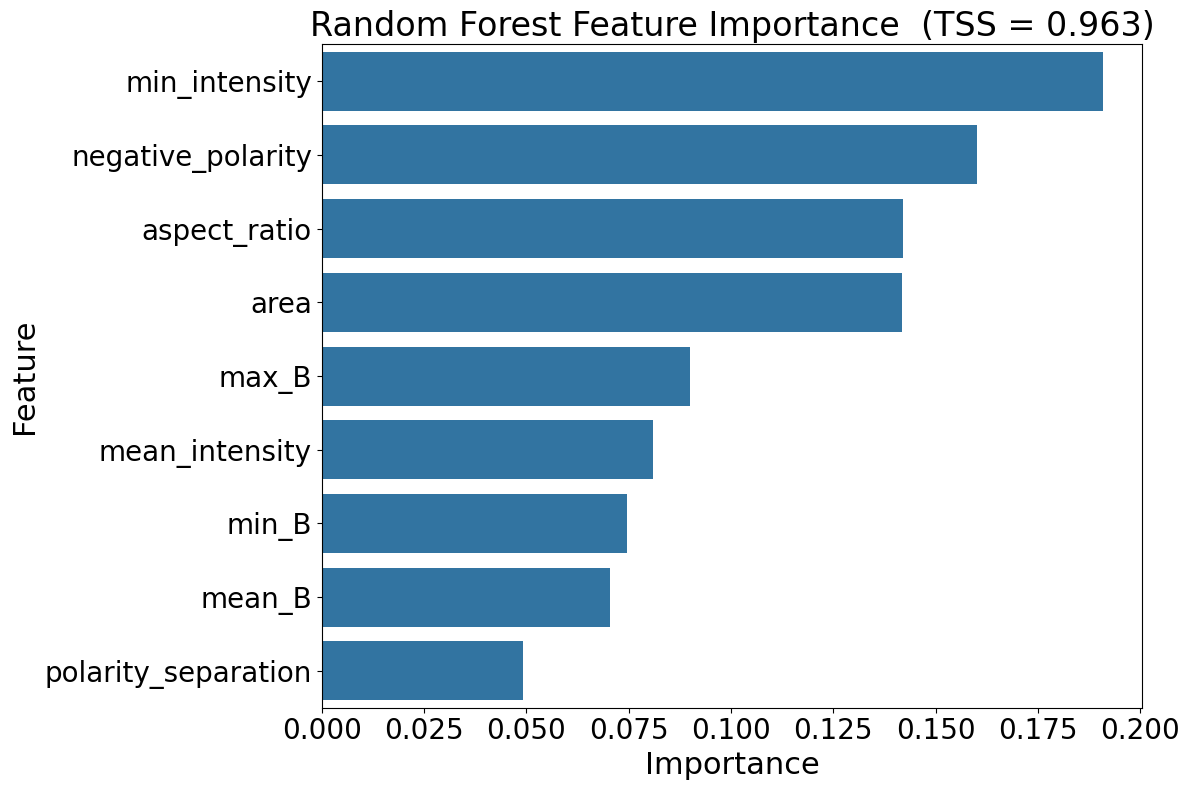

In [27]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Features and target
X = df_balanced[params_corr]
y = df_balanced['is_flare']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Evaluate model
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-flare', 'Flare']))

# Compute TSS from confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn)  # True Positive Rate
far = fp / (fp + tn)          # False Alarm Rate
tss = sensitivity - far
print(f"TSS: {tss:.3f}")

# Feature importance
importances = rf_model.feature_importances_

feat_importance_df = pd.DataFrame({
    'feature': params_corr,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_importance_df)


# Plot feature importance

plot_df = feat_importance_df.copy()

plot_df['feature'] = plot_df['feature'].replace({
    'negative_flux': 'negative_polarity'
})
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=plot_df,
            x='importance',
            y='feature')
ax.tick_params(axis='both', labelsize=20)

plt.title(f"Random Forest Feature Importance  (TSS = {tss:.3f})", fontsize=24)
plt.xlabel("Importance", fontsize = 22)
plt.ylabel("Feature", fontsize = 22)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

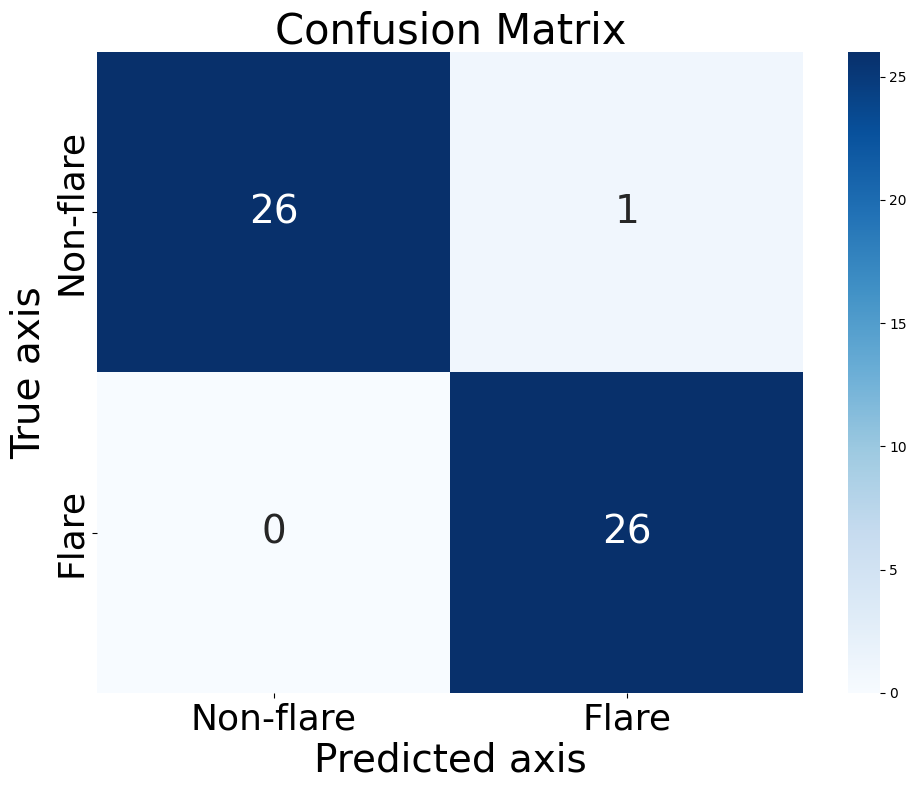

In [25]:

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-flare', 'Flare'],
            yticklabels=['Non-flare', 'Flare'],
            annot_kws={"size": 28})

ax.tick_params(axis='both', labelsize=26)
plt.xlabel('Predicted axis', fontsize=28)
plt.ylabel('True axis', fontsize = 28)
plt.title('Confusion Matrix', fontsize=30)
plt.tight_layout()
plt.savefig('confusionmatrix.png')
plt.show()